In [15]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cpu


In [16]:
def extract_patches(img, patch_size=32):
    patches = []
    _, H, W = img.shape

    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            patch = img[:, i:i+patch_size, j:j+patch_size]
            if patch.shape[1] == patch_size and patch.shape[2] == patch_size:
                patches.append(patch)

    return torch.stack(patches)  # (num_patches, 3, 32, 32)

In [17]:
class PCAM_MIL_Dataset(Dataset):
    def __init__(self, x_path, y_path, indices, transform=None):
        self.transform = transform

        print("Loading data...")
        with h5py.File(x_path, 'r') as x_file, \
             h5py.File(y_path, 'r') as y_file:

            self.images = x_file['x'][indices]
            self.labels = y_file['y'][indices].reshape(-1)

        print("Loaded:", len(self.images))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.uint8)
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        patches = extract_patches(img)  # 🔥 key step

        return patches, torch.tensor(label, dtype=torch.float32)

In [18]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize([0.7,0.5,0.7], [0.2,0.2,0.2])
])

In [19]:
def get_indices(path, n):
    with h5py.File(path, 'r') as f:
        total = len(f['x'])
    return random.sample(range(total), n)

train_idx = get_indices("pcam/camelyonpatch_level_2_split_train_x.h5", 5000)
val_idx   = get_indices("pcam/camelyonpatch_level_2_split_valid_x.h5", 1000)

In [20]:
train_idx = sorted(get_indices(
    "pcam/camelyonpatch_level_2_split_train_x.h5", 5000
))

val_idx = sorted(get_indices(
    "pcam/camelyonpatch_level_2_split_valid_x.h5", 1000
))

In [21]:
train_dataset = PCAM_MIL_Dataset(
    "pcam/camelyonpatch_level_2_split_train_x.h5",
    "pcam/camelyonpatch_level_2_split_train_y.h5",
    train_idx,
    transform
)

val_dataset = PCAM_MIL_Dataset(
    "pcam/camelyonpatch_level_2_split_valid_x.h5",
    "pcam/camelyonpatch_level_2_split_valid_y.h5",
    val_idx,
    transform
)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

Loading data...
Loaded: 5000
Loading data...
Loaded: 1000


In [22]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(base.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

In [23]:
class AttentionMIL(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, H):
        A = self.attention(H)
        A = torch.softmax(A, dim=0)
        M = torch.sum(A * H, dim=0)
        return M, A

In [24]:
class MILModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = FeatureExtractor()
        self.attention = AttentionMIL(512)

        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, patches):
        H = self.encoder(patches)
        M, A = self.attention(H)
        out = self.classifier(M)
        return out, A

In [25]:
def train_model(model, train_loader, val_loader, epochs=10):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    history = {"train_loss":[], "val_loss":[]}

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # ---- TRAIN ----
        model.train()
        train_loss = 0

        for patches, label in tqdm(train_loader, desc="Train"):
            patches = patches.squeeze(0).to(device)
            label = label.to(device)

            output, _ = model(patches)
            output = output.view(-1)

            loss = criterion(output, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ---- VAL ----
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for patches, label in tqdm(val_loader, desc="Val"):
                patches = patches.squeeze(0).to(device)
                label = label.to(device)

                output, _ = model(patches)
                output = output.view(-1)

                loss = criterion(output, label)
                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")

    return history

In [26]:
def plot_training(history):
    plt.plot(history['train_loss'], label="Train")
    plt.plot(history['val_loss'], label="Val")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

In [27]:
def visualize_attention(model, dataset, idx=0):
    model.eval()

    patches, label = dataset[idx]
    patches = patches.to(device)

    _, A = model(patches)

    A = A.detach().cpu().numpy().flatten()

    plt.bar(range(len(A)), A)
    plt.title("Patch Attention Weights")
    plt.show()

c:\Users\sarah\OncoPRISM\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sarah\OncoPRISM\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sarah/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 5.99MB/s]



Epoch 1/10


Val: 100%|██████████| 1000/1000 [00:25<00:00, 38.86it/s]


...

Train Loss: 0.3675
Val Loss:   2.2890

Epoch 9/10


Val: 100%|██████████| 1000/1000 [00:35<00:00, 28.30it/s]


Train Loss: 0.3156
Val Loss:   6.6668

Epoch 10/10


Val: 100%|██████████| 1000/1000 [00:35<00:00, 28.07it/s]


Train Loss: 0.2599
Val Loss:   3.0858


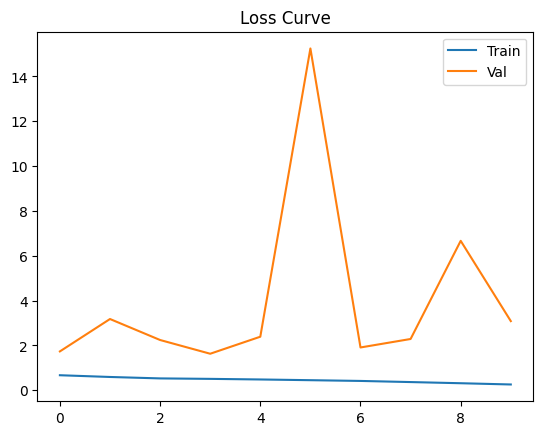

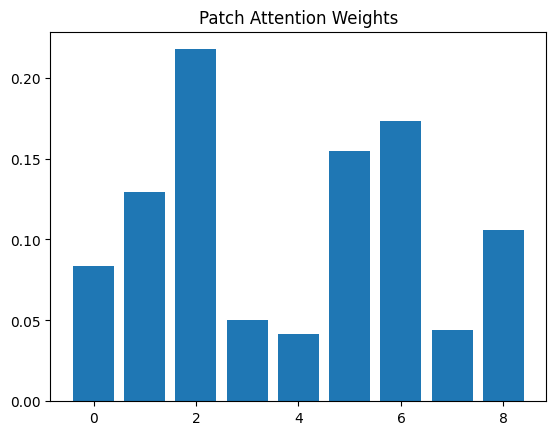

In [28]:
model = MILModel().to(device)

history = train_model(model, train_loader, val_loader, epochs=10)

plot_training(history)

visualize_attention(model, train_dataset, idx=0)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

def evaluate_model(model, loader):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for patches, label in tqdm(loader, desc="Evaluating"):
            patches = patches.squeeze(0).to(device)
            label = label.to(device)

            output, _ = model(patches)
            prob = torch.sigmoid(output).item()
            pred = 1 if prob > 0.5 else 0

            all_labels.append(label.item())
            all_preds.append(pred)
            all_probs.append(prob)

    # ---- Metrics ----
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print("\n🔥 FINAL METRICS")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    # ---- Confusion Matrix ----
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

Evaluating: 100%|██████████| 1000/1000 [00:29<00:00, 33.89it/s]



🔥 FINAL METRICS
Accuracy  : 0.4420
Precision : 0.4459
Recall    : 0.5621
F1 Score  : 0.4973
ROC-AUC   : 0.4989


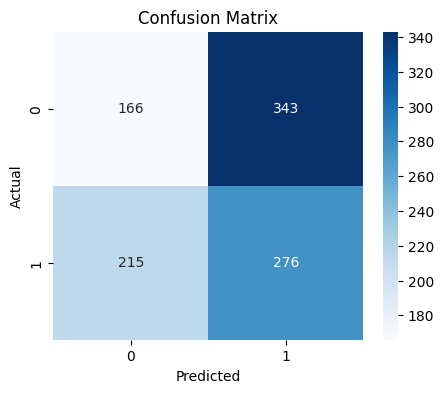

In [30]:
metrics = evaluate_model(model, val_loader)

In [31]:
from sklearn.metrics import roc_curve

def plot_roc(model, loader):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for patches, label in loader:
            patches = patches.squeeze(0).to(device)

            output, _ = model(patches)
            prob = torch.sigmoid(output).item()

            all_probs.append(prob)
            all_labels.append(label.item())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()